# EDS 217 Final Project: "The Twos"

Members: Kelly Morgan, Oliver Witt, Natasha Clemencon

[Session Webpage](https://eds-217-essential-python.github.io/course-materials/interactive-sessions/7d_project_kickoff.html)

Date: 09/09/2026


## 1. Import Data


In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import requests

def extract_file_id(url):
    """Extract file id from Google Drive Sharing URL."""
    return url.split("/")[-2]

def df_from_gdrive_csv(url):
    """ Get the CSV file from a Google Drive Sharing URL."""
    file_id = extract_file_id(url)
    URL = "https://docs.google.com/uc?export=download"
    session = requests.Session()
    response = session.get(URL, params={"id": file_id}, stream=True)
    return pd.read_csv(response.raw)

# Example of how to use:
# Note: your sharing link will be different, but should look like this:
sharing_url = "https://drive.google.com/file/d/1Fnt_dR8Iwes_Fz72mVG_86c3ZUZobIX0/view?usp=sharing"
spotify = df_from_gdrive_csv(sharing_url)
spotify.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390



## 2. Explore Data


In [153]:
spotify.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [154]:
spotify['genre'].unique()

array(['Movie', 'R&B', 'A Capella', 'Alternative', 'Country', 'Dance',
       'Electronic', 'Anime', 'Folk', 'Blues', 'Opera', 'Hip-Hop',
       "Children's Music", 'Children’s Music', 'Rap', 'Indie', 'Classical',
       'Pop', 'Reggae', 'Reggaeton', 'Jazz', 'Rock', 'Ska', 'Comedy', 'Soul',
       'Soundtrack', 'World'], dtype=object)

In [182]:
# also, we need to combine the two different spellings 
# of "children's music" first into one genre
spotify['genre'] = spotify['genre'].str.replace('Children’s', 'Childrens')
spotify['genre'] = spotify['genre'].str.replace("Children's", 'Childrens')
 
spotify['genre'].unique()

array(['Movie', 'R&B', 'A Capella', 'Alternative', 'Country', 'Dance',
       'Electronic', 'Anime', 'Folk', 'Blues', 'Opera', 'Hip-Hop',
       'Childrens Music', 'Rap', 'Indie', 'Classical', 'Pop', 'Reggae',
       'Reggaeton', 'Jazz', 'Rock', 'Ska', 'Comedy', 'Soul', 'Soundtrack',
       'World'], dtype=object)

In [155]:
print(spotify.shape)
spotify.isnull().sum()

(232725, 18)


genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

## 3. Clean Data


In [156]:
# Drop NAs
spotify = spotify.dropna()
print(spotify.shape, "<- one row dropped")
spotify.isnull().sum()

(232724, 18) <- one row dropped


genre               0
artist_name         0
track_name          0
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

In [ ]:
# Remove duplicates-- there's a lot!
spotify = spotify.drop_duplicates(subset=['artist_name', 'track_name'])
print(spotify.shape)
print(232724-176513,"rows dropped")

(176513, 18)
56211 rows dropped


In [ ]:
# Filtering by desired genres: Pop, Rap, Classical, and Opera
spotify_filtered = spotify[spotify['genre'].isin(['Pop', 'Rap', 'Classical', 'Opera'])]
spotify_filtered['genre'].unique()

# Create dataframe for each genre
opera = spotify_filtered[spotify_filtered['genre']== 'Opera']
classical = spotify_filtered[spotify_filtered['genre']== 'Classical']
pop = spotify_filtered[spotify_filtered['genre']== 'Pop']
rap = spotify_filtered[spotify_filtered['genre']== 'Rap']

array(['Opera', 'Rap', 'Classical', 'Pop'], dtype=object)

## Three Questions

### What is the difference in tempo across our genres of interest: Pop, Rap, Classical, and Opera?

In [180]:
#Look at the mean tempos for each of the four genres, and sort them
#to see which genres have a higher mean tempo
opera['tempo'].mean()
classical['tempo'].mean()
rap['tempo'].mean()
pop['tempo'].mean()

spotify_filtered.groupby('genre')['tempo'].mean().sort_values()

genre
Opera        101.802977
Classical    104.497091
Rap          120.966620
Pop          123.288257
Name: tempo, dtype: float64

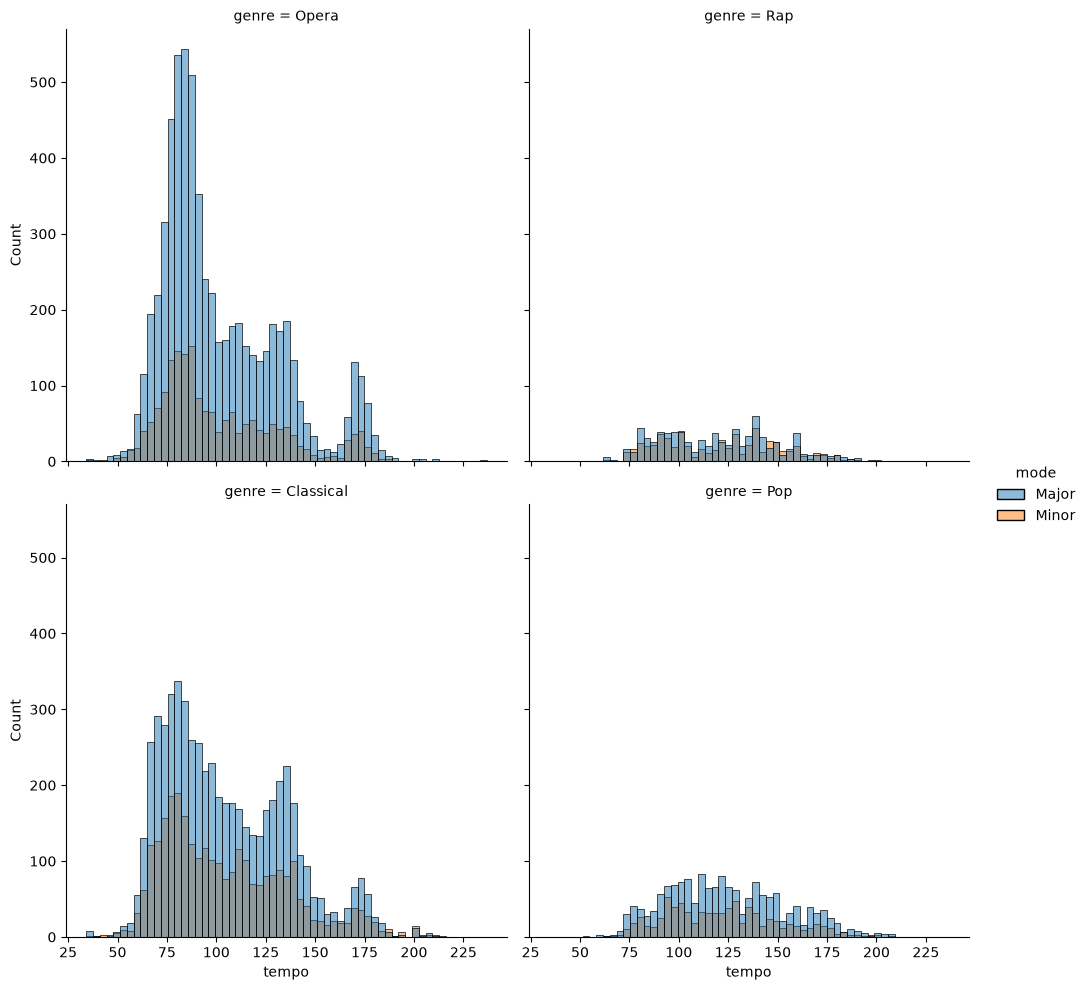

In [181]:
#Graph the tempos for each of the four genres 
sns.displot(
    spotify_filtered,
    x="tempo",
    col="genre",
    hue="mode",
    col_wrap=2,
    facet_kws=dict(margin_titles=True)
)

## How does song length vary across genre? How does this effect popularity? 

In [183]:
# which genre has longer songs?
grouped = spotify_filtered.groupby('genre')['duration_ms'].agg(['mean', 'max', 'min', 'count'])
filtered_df = grouped.reset_index()
filtered_df

,genre,mean,max,min,count
0,Classical,312981.590256,3391040,15509,8703
1,Opera,259161.092271,2404810,30707,8280
2,Pop,218439.330705,645876,89520,2410
3,Rap,201944.816495,760973,49242,1455


In [184]:
# how many rows does each of these have? 
# (i.e. how many songs does each genre have?)

print(f"there are {len(classical)} classical songs")
print(f"there are {len(opera)} opera songs")
print(f"there are {len(pop)} pop songs")
print(f"there are {len(rap)} rap songs")

there are 8703 classical songs
there are 8280 opera songs
there are 2410 pop songs
there are 1455 rap songs


In [ ]:
# filter for songs above a certain threshold
# lets say a "long" song is over eight minutes
# 8 minutes is 480,000 milliseconds

# then calculate proportion of songs of a
# certain genre that are "long"


long_classical = classical[classical['duration_ms'] > 480000]
print(f"there are {len(long_classical)} long classical songs")
percent_classical = ((len(long_classical)) / (len(classical))) * 100
print(f"{round(percent_classical, 2)}% of classical songs are long")

print(" ")

long_opera = opera[opera['duration_ms'] > 480000]
print(f"there are {len(long_opera)} long opera songs")
percent_opera = ((len(long_opera)) / (len(opera))) * 100
print(f"{round(percent_opera, 2)}% of opera songs are long")

print(" ")

long_pop = pop[pop['duration_ms'] > 480000]
print(f"there are {len(long_pop)} long pop songs")
percent_pop = ((len(long_pop)) / (len(pop))) * 100
print(f"{round(percent_pop, 2)}% of pop songs are long")

print(" ")

long_rap = rap[rap['duration_ms'] > 480000]
print(f"there are {len(long_rap)} long rap songs")
percent_rap = ((len(long_rap)) / (len(rap))) * 100
print(f"{round(percent_rap, 2)}% of rap songs are long")

In [185]:
# create and apply function to classify songs as
# long/normal/short

def islong(d):
    if d > 480000:
        return "long"
    elif d < 180000:
        return "short"
    else:
        return "normal"

spotify_filtered['is long?'] = spotify_filtered['duration_ms'].apply(islong)

# gives a warning message but works!

<positron-console-cell-185>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


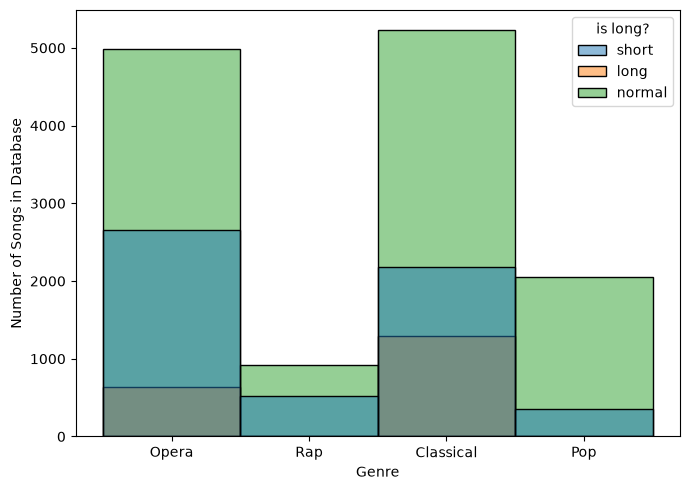

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [186]:
# Plot relative counts of
# song length cateogires for
#  our three selected genres
plt.figure(figsize=(7, 5))
sns.histplot(data=spotify_filtered, x='genre', hue='is long?')
plt.xlabel('Genre')
plt.ylabel('Number of Songs in Database')
plt.tight_layout()
plt.show()
print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")

In [ ]:
# compare popularity of long vs not long songs
# within these three selected genres

song_long = spotify_filtered.groupby('is long?')['popularity'].mean().reset_index()
sns.barplot(data=song_long, x='is long?', y='popularity')
plt.xlabel('Song Length')
plt.ylabel('Song Popularity')
plt.tight_layout()
plt.show()

print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")

## Same figures with the WHOLE database (all genres)

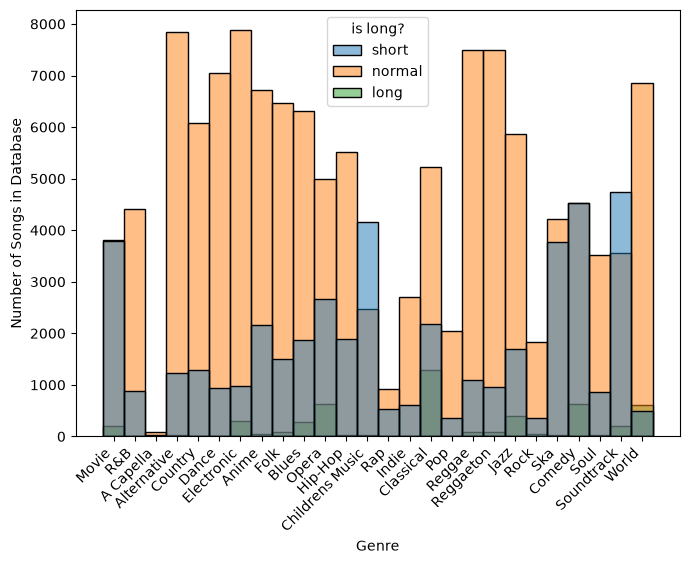

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [187]:
#go back and look at the WHOLE database:


spotify['is long?'] = spotify['duration_ms'].apply(islong)


plt.figure(figsize=(7, 5))
sns.histplot(data=spotify, x='genre', hue='is long?')
plt.xlabel('Genre')
plt.ylabel('Number of Songs in Database')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()
print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")

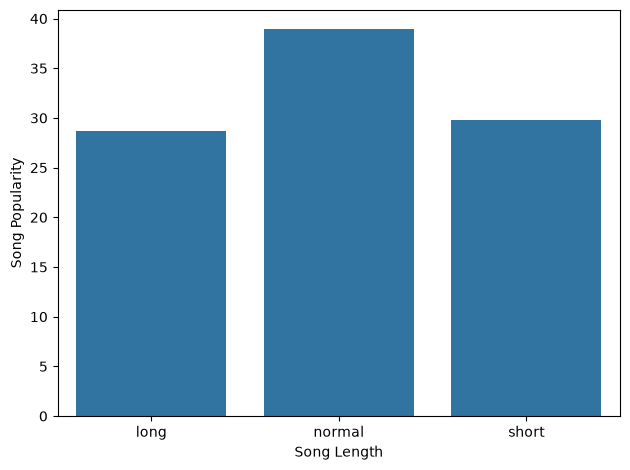

Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes


In [188]:
all_song_long = spotify.groupby('is long?')['popularity'].mean().reset_index()
sns.barplot(data=all_song_long, x='is long?', y='popularity')
plt.xlabel('Song Length')
plt.ylabel('Song Popularity')
plt.tight_layout()
plt.show()

print("Key: 'Long' = longer than 8 minutes; 'Short' = shorter than 3 minutes")

## What is the most common key across all genres of music? How do the most common keys differ between our genres of interest?

### Filter Data:


In [ ]:
### key distribution across ALL genres ###

# keep columns genre and key
keep_cols = ['genre', 'key']

# filter dataframe and group by key, aggregate by count
all_genres = spotify[keep_cols].groupby(['key'])['key'].count()

# reset the index and give the aggregation a column name, then sort by descending
all_genres_key = all_genres.reset_index(name='count').sort_values(['count'], ascending=False)

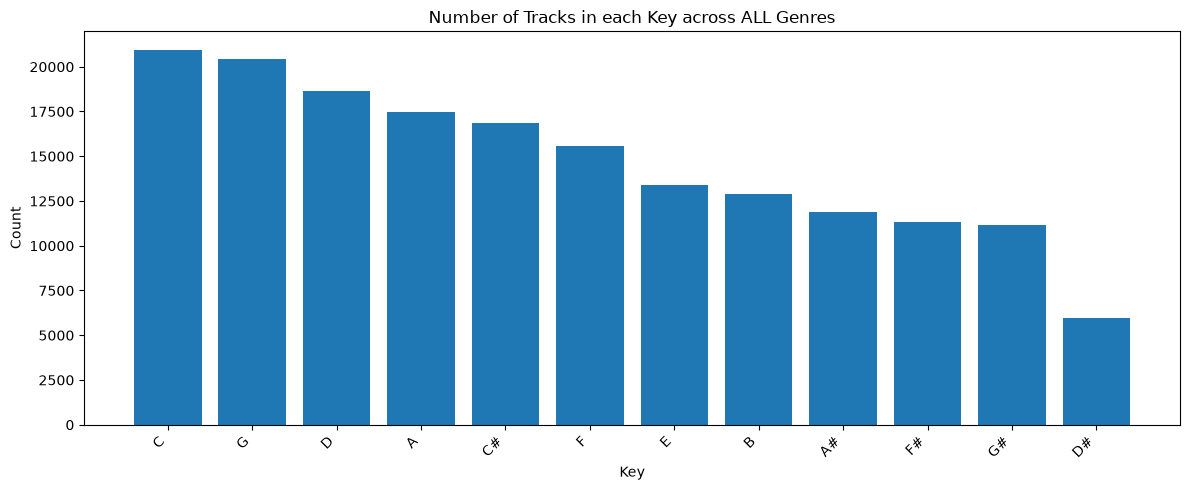

In [ ]:
### Plot Number of Tracks in each Key across ALL Genres ###

plt.figure(figsize= (12, 5)) # 15 inch wide, 3 inch tall
plt.xticks(rotation=45, ha='right')

plt.bar(all_genres_key['key'], all_genres_key['count'])
plt.title("Number of Tracks in each Key across ALL Genres")
plt.xlabel('Key')
plt.ylabel('Count')

plt.tight_layout()

plt.show()

### Group, Aggregate, and Sort Data:



In [168]:
### key distribution across four desired genres ###

# Use spotify_filtered to groupby genre and key
genre_grouped = spotify_filtered[keep_cols].groupby(['genre', 'key'])['key'].count()
# reset.index() and rename cols
genre_grouped = genre_grouped.reset_index(name='count').sort_values(['count'], ascending=False)
genre_grouped.head(12) # 12 keys

,genre,key,count
10,Classical,G,1073
5,Classical,D,1048
3,Classical,C,1045
15,Opera,C,919
20,Opera,F,913
17,Opera,D,908
22,Opera,G,862
8,Classical,F,846
0,Classical,A,807
7,Classical,E,737


### Transform, Join, and Reshape Data:


In [169]:
# pivot table 
keys_pivot = genre_grouped.pivot_table(
    index='genre',
    columns='key',
    values='count'
)
keys_pivot

key,A,A#,B,C,C#,D,D#,E,F,F#,G,G#
genre,,,,,,,,,,,,
Classical,807.0,618.0,409.0,1045.0,686.0,1048.0,560.0,737.0,846.0,433.0,1073.0,441.0
Opera,665.0,656.0,381.0,919.0,649.0,908.0,598.0,705.0,913.0,382.0,862.0,642.0
Pop,206.0,166.0,194.0,279.0,226.0,225.0,101.0,188.0,226.0,171.0,241.0,187.0
Rap,127.0,118.0,118.0,145.0,230.0,140.0,36.0,73.0,107.0,102.0,133.0,126.0


### Visualize Data

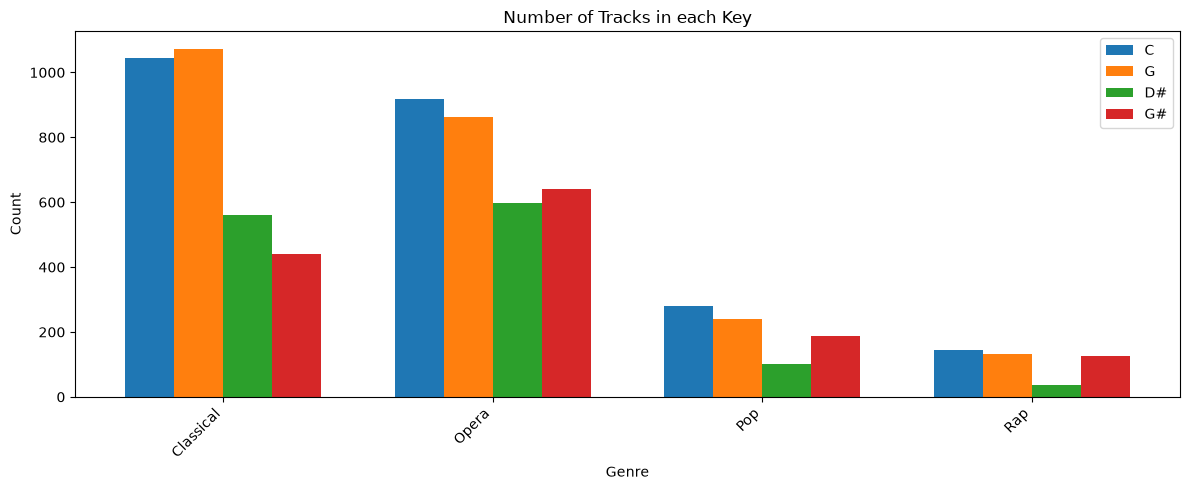

In [170]:
# Genres : Pop, Rap, Classical, Opera
# Keys: 'C', 'G', 'D#', 'G#'

keys = ['C', 'G', 'D#', 'G#']
pick_keys = keys_pivot[keys]

plt.figure(figsize= (12, 5)) # 15 inch wide, 3 inch tall
plt.xticks(rotation=45, ha='right')

plt.grouped_bar(pick_keys.to_numpy(), tick_labels=pick_keys.index, labels=pick_keys.columns)
plt.title("Number of Tracks in each Key")
plt.xlabel('Genre')
plt.ylabel('Count')

plt.tight_layout()
plt.legend()

In [171]:
# How many tracks are in each genre?
pick_keys

key,C,G,D#,G#
genre,,,,
Classical,1045.0,1073.0,560.0,441.0
Opera,919.0,862.0,598.0,642.0
Pop,279.0,241.0,101.0,187.0
Rap,145.0,133.0,36.0,126.0


In [ ]:
### Take random sample of datasets to normallize ###

opera = spotify_filtered[spotify_filtered['genre']== 'Opera']
classical = spotify_filtered[spotify_filtered['genre']== 'Classical']
pop = spotify_filtered[spotify_filtered['genre']== 'Pop']
rap = spotify_filtered[spotify_filtered['genre']== 'Rap']

opera_samp = opera.sample(100)
classical_samp = classical.sample(100)
pop_samp = pop.sample(100)
rap_samp = rap.sample(100)

combined_samp = pd.concat([opera_samp, classical_samp, pop_samp, rap_samp]).reset_index()

In [ ]:
### Replicating groupby process ###
combined_samp_grouped = combined_samp[keep_cols].groupby(['genre', 'key'])['key'].count()
combined_samp_grouped = combined_samp_grouped.reset_index(name='count').sort_values(['count'], ascending=False)

# pivot table 
combined_pivot = combined_samp_grouped.pivot_table(
    index='genre',
    columns='key',
    values='count'
)
combined_pivot

key,A,A#,B,C,C#,D,D#,E,F,F#,G,G#
genre,,,,,,,,,,,,
Classical,9.0,8.0,4.0,13.0,8.0,10.0,4.0,10.0,9.0,7.0,13.0,5.0
Opera,7.0,7.0,3.0,9.0,5.0,12.0,7.0,7.0,15.0,4.0,15.0,9.0
Pop,8.0,2.0,12.0,8.0,16.0,12.0,4.0,5.0,9.0,7.0,6.0,11.0
Rap,7.0,5.0,5.0,10.0,16.0,11.0,5.0,4.0,4.0,11.0,11.0,11.0


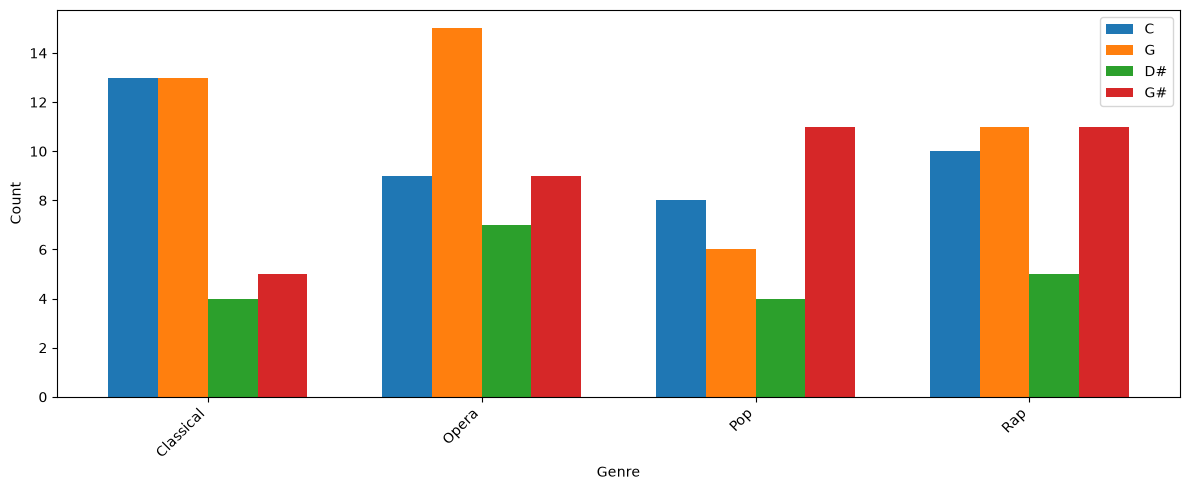

In [179]:
keys = ['C', 'G', 'D#', 'G#']
pick_keys = combined_pivot[keys]

plt.figure(figsize= (12, 5)) # 15 inch wide, 3 inch tall
plt.xticks(rotation=45, ha='right')

plt.grouped_bar(pick_keys.to_numpy(), tick_labels=pick_keys.index, labels=pick_keys.columns)
plt.xlabel('Genre')
plt.ylabel('Count')

plt.tight_layout()
plt.legend()

oliver code